In [1]:
import os
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import numpy.random as nr
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import scipy
import pickle

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))

from src.nre.safe_routing import communication_graph_from_df
from src.nre.preprocess import preprocess_df
from src.nre.network_connectivity import ConnectivityUnit

In [2]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv' 
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')
df = preprocess_df(df_cic, date_col=' Timestamp')
df = df.iloc[:200_000]

In [4]:
df

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
133037,192.168.10.25-54.192.37.17-54988-443-6,54.192.37.17,443,192.168.10.25,54988,6,2017-04-07 01:00:00,54,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
394262,192.168.10.9-87.250.250.119-5303-443-6,87.250.250.119,443,192.168.10.9,5303,6,2017-04-07 01:00:00,101114,2,1,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
132995,192.168.10.25-52.84.145.136-54978-443-6,192.168.10.25,54978,52.84.145.136,443,6,2017-04-07 01:00:00,169399,22,30,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
132994,192.168.10.9-87.250.250.119-5260-443-6,192.168.10.9,5260,87.250.250.119,443,6,2017-04-07 01:00:00,148,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
138980,192.168.10.12-199.182.221.110-123-123-17,192.168.10.12,123,199.182.221.110,123,17,2017-04-07 01:00:00,71771,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266033,192.168.10.17-64.94.116.26-40949-80-6,192.168.10.17,40949,64.94.116.26,80,6,2017-04-07 04:39:00,116870729,71,95,...,32,142021.0909,191199.6645,718509.0,83965.0,10000000.0,22807.69714,10000000.0,9951993.0,BENIGN
266032,192.168.10.17-64.94.116.26-40950-80-6,192.168.10.17,40950,64.94.116.26,80,6,2017-04-07 04:39:00,116870217,166,308,...,32,186467.5455,338682.026,1207632.0,83999.0,10000000.0,7834.448964,10000000.0,10000000.0,BENIGN
410623,192.168.10.3-192.168.10.5-53-63994-17,192.168.10.5,63994,192.168.10.3,53,17,2017-04-07 04:39:00,110565,4,2,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
266031,192.168.10.17-38.69.238.17-55308-80-6,192.168.10.17,55308,38.69.238.17,80,6,2017-04-07 04:39:00,115518948,20,19,...,32,73229.09091,136574.0049,485015.0,31905.0,10000000.0,6283.803391,10000000.0,9997747.0,BENIGN


In [23]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [3]:
with open(r'saves\partitioned_nodes_141.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [4]:
with open(r'saves\monday_759.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [4]:
g = communication_graph_from_df(df, entity_names, keep_outsiders=False, spanning_tree=True)
entity_names = list(g.nodes)
len(g), len(entity_names)

(141, 141)

In [11]:
import src.nre.network_connectivity, importlib

importlib.reload(src.nre.network_connectivity)
from src.nre.network_connectivity import*

In [12]:
cu = ConnectivityUnit()
cu.read_flows(df, conn_param='NPR', entity_names=entity_names,
             window_type= 'time', sync_window_size= 1.2, time_scale= 'sec')

cu.fit_connectivity_model(method = 'cov') # cov


Conditioning number:  1755650692959384.8 
Determinant of F^T*F:  -1.980286935854556e-22


In [13]:
cu.mat_f.shape

(141, 141)

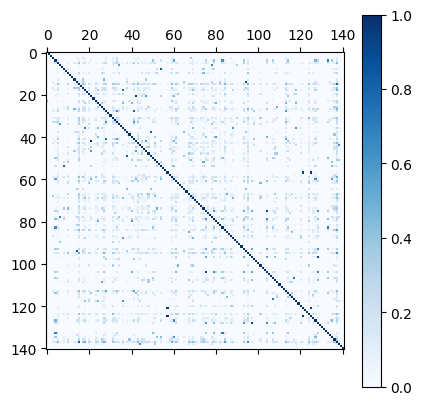

In [14]:
plt.matshow(cu.mat_f, cmap='Blues')
plt.colorbar()

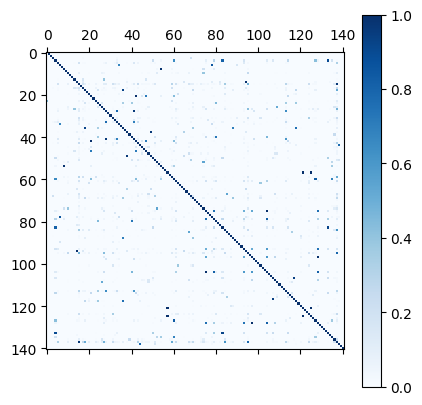

In [15]:
mat_f = cu.suppress_f(degree= 2, inplace=False)
plt.matshow(mat_f, cmap='Blues')
plt.colorbar()

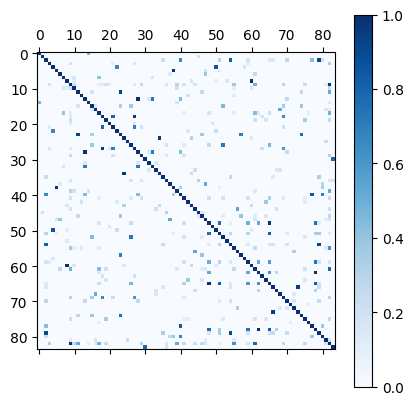

In [16]:
# Cleanup mat_f
cu.suppress_f(degree= 2)
cu.clip_f(0.1, inplace=True)
sub_cus = cu.get_connected_units()

cu = sub_cus[0]
mat_f = cu.mat_f.copy()
entity_names = cu.names

plt.matshow(mat_f, cmap='Blues')
plt.colorbar()

#g_f = nx.from_numpy_array(mat_f - np.diag(np.diag(mat_f)))
#nx.relabel_nodes(g_f, {i:name for i, name in enumerate(entity_names)}, copy=False)
#entity_names = sublist[0].names

In [17]:
len(entity_names), len(cu.names)

(84, 84)

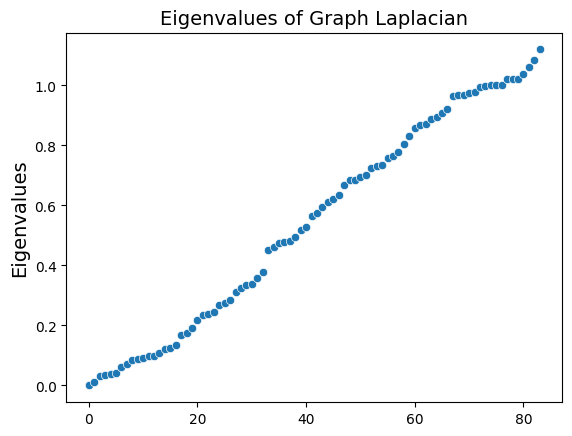

0.991139874808515
[-2.28983499e-16  1.32331958e-02  3.11023333e-02  3.37280890e-02
  3.97263614e-02  4.26736913e-02  6.11919684e-02  7.22487759e-02
  8.37120265e-02  8.68442834e-02]


In [19]:
from src.nre.network_partitioning import get_eig_vals_err

cu.clip_f(0.1, inplace=True)
eigvals, err = get_eig_vals_err(cu.mat_f, cu.names)

print(err)
print(eigvals[:10])

In [22]:
cu_list = cu.get_connected_units()
[unit.mat_f.shape[0] for unit in cu_list]

[84]

In [21]:
cu2 = cu_list[0]

In [22]:
from src.network_connectivity import apply_partitioning


cu_list = apply_partitioning(cu2, 2, plot_bool=True)
#cu2 = cu_list[4]

NameError: name 'cu2' is not defined

In [23]:
cu_list

In [24]:
cu2 = cu_list[0]
cu2.mat_f.shape

(95, 95)

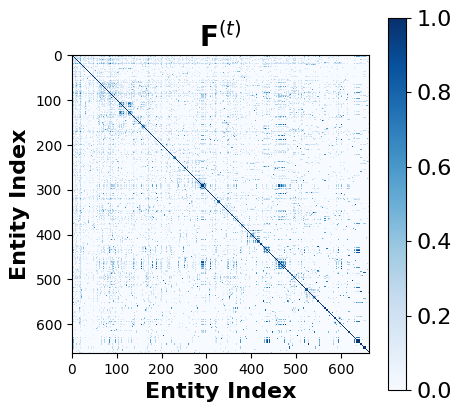

<Figure size 640x480 with 0 Axes>

In [27]:
cu2.plot_f()

In [35]:
cu = cu2
entity_names = cu2.names

In [18]:
import src.network_connectivity, importlib

importlib.reload(src.network_connectivity)
from src.network_connectivity import*

In [23]:
with open(r'saves\connected_84.pickle', 'wb') as handle: # sample_nodes.pickle
    pickle.dump(entity_names, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [5]:
with open(r'saves\connected_84.pickle', 'rb') as handle: # sample_nodes.pickle
    entity_names = pickle.load(handle) 

In [6]:
len(entity_names)

84

In [7]:
from src.nre.kalman_network_tools import get_risk_mat_from_df


risk_mat, labels, labels_count, _, _, all_cov = get_risk_mat_from_df(df, entity_names=entity_names, t_graph=90, sync_window_size=1.2,
                                                                    return_cov=True)
risk_mean, risk_cov = risk_mat[-1,:], all_cov[-1]

cu.fit_nx_graph()
with open(r'saves\layout_small1.pickle', 'wb') as handle: # sample_nodes.pickle
    pickle.dump((risk_mean, risk_cov, cu.mat_f, cu.g, entity_names), handle, protocol=pickle.HIGHEST_PROTOCOL)

mat_f = cu.mat_f
mat_f = mat_f - np.diag(np.diag(mat_f))

1
Current time and samples shape:  2017-04-07 01:02:00 (75, 84)
2
Current time and samples shape:  2017-04-07 01:04:00 (75, 84)
3
Current time and samples shape:  2017-04-07 01:06:00 (75, 84)
4
Current time and samples shape:  2017-04-07 01:08:00 (75, 84)
5
Current time and samples shape:  2017-04-07 01:10:00 (75, 84)
6
Current time and samples shape:  2017-04-07 01:12:00 (75, 84)
7
Current time and samples shape:  2017-04-07 01:14:00 (75, 84)
8
Current time and samples shape:  2017-04-07 01:16:00 (75, 84)
9
Current time and samples shape:  2017-04-07 01:18:00 (75, 84)
10
Current time and samples shape:  2017-04-07 01:20:00 (75, 84)
11
Current time and samples shape:  2017-04-07 01:22:00 (75, 84)
12
Current time and samples shape:  2017-04-07 01:24:00 (75, 84)
13
Current time and samples shape:  2017-04-07 01:26:00 (75, 84)
14
Current time and samples shape:  2017-04-07 01:28:00 (75, 84)
15
Current time and samples shape:  2017-04-07 01:30:00 (75, 84)
16
Current time and samples shape:

KeyboardInterrupt: 

In [8]:
with open(r'saves\layout_medium1.pickle', 'rb') as handle:
    risk_mean, risk_cov, mat_f, g_f, entity_names = pickle.load(handle) 

mat_f = mat_f - np.diag(np.diag(mat_f))
mat_f.shape

(84, 84)

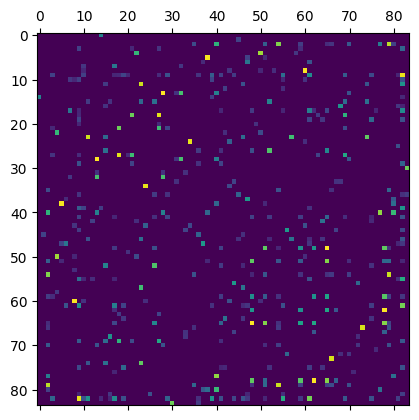

In [9]:
plt.matshow(mat_f)

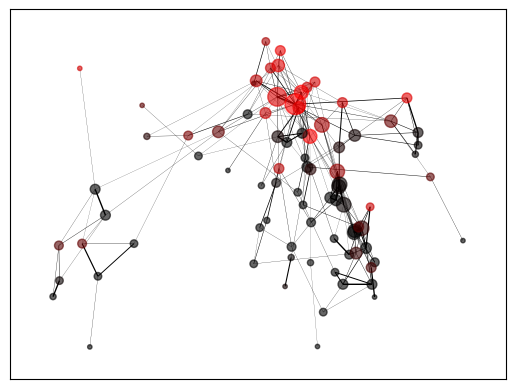

In [10]:
import matplotlib
from src.nre.network_plotting import risk_elevation_layout

fig, ax = plt.subplots()
widths = [g_f[u][v]['weight'] for u,v in g_f.edges]
nodesizes = [v * 10 for v in dict(g_f.degree).values()]
pos_f = risk_elevation_layout(g_f, risks=risk_mean, alpha=200, seed=29, iterations=500,  method=None)
#pos_f = nx.spring_layout(g_f, seed=29, iterations=500) # 28, 32,, 29
#pos_f = nx.kamada_kawai_layout(g_f)
#pos_f = nx.spectral_layout(g_f)

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["black","red"])
nx.draw_networkx_nodes(g_f, pos=pos_f, node_color=risk_mean, cmap=cmap, #with_labels=False,
        node_size=nodesizes, alpha=0.6)
nx.draw_networkx_edges(g_f, pos=pos_f, width=widths)
        
norm = matplotlib.colors.Normalize(vmin=min(risk_mean), vmax=max(risk_mean))
#cbar = plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.1, shrink=1)
#cbar.set_label('Mean Risks', labelpad=-65, fontsize = 12)
#plt.margins(x=0.2)
#plt.tight_layout()

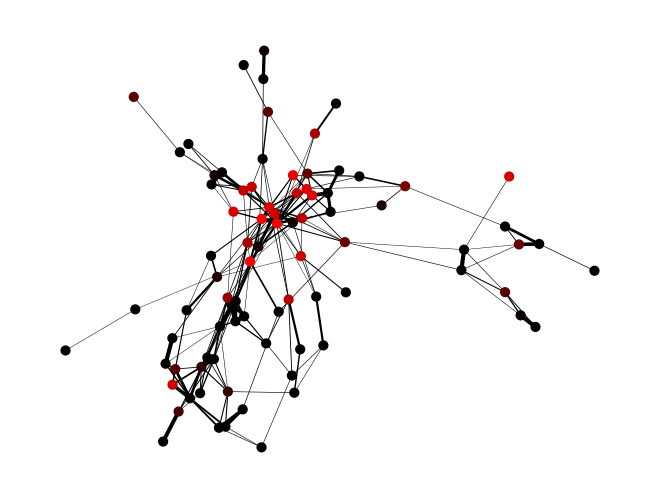

In [33]:
from src.nre.network_plotting import risk_elevation_layout

#cmap = plt.cm.Reds
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["black","red"])

widths = [3*g_f[u][v]['weight'] for u,v in g_f.edges]
pos_f = risk_elevation_layout(g_f, risks=risk_mean, alpha=2, seed=28, iterations=500)
# pos_f = nx.spring_layout(g_f, seed=28, iterations=500)
nx.draw(g_f, pos=pos_f, width=widths, node_color=risk_mean, cmap=cmap, with_labels=False, node_size=40)

In [11]:
import src.nre.network_plotting, importlib

importlib.reload(src.nre.network_plotting)
from src.nre.network_plotting import*

In [12]:
g_relabeled, new_labels, clusters = apply_spec_clus(mat_f, entity_names, 1, plot_bool=False)

In [13]:
len(g_relabeled), len(new_labels)

(84, 84)

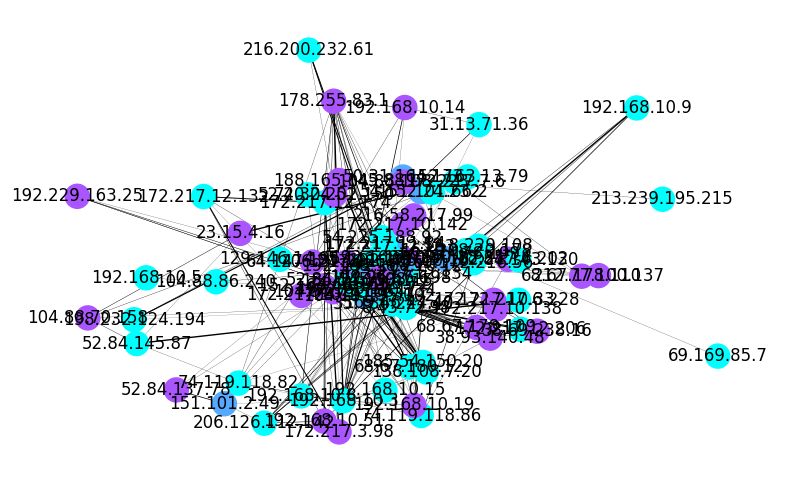

In [14]:
from src.nre.network_plotting import pie_layout

d_xy, d_z = 1.3, 2
n_cluster = 3
layout, risk_mean, risk_cov, node_colors, r, g_out, clus_assgn = pie_layout(mat_f, entity_names, n_cluster, risk_mean=risk_mean,
                                                                           risk_cov=risk_cov, d_xy=d_xy, d_z=d_z, r_const=2.5, alpha=2,
                                                                           plot_bool=True, with_labels=True)

C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\networkx\drawing\nx_pylab.py:450: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


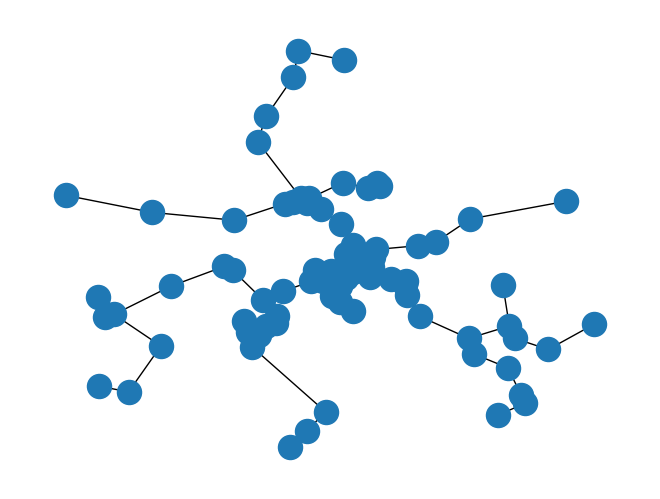

In [41]:
from src.nre.network_plotting import get_layout_tree

g_skeletal = get_layout_tree(g_f, layout)
nx.draw(g_skeletal, pos=layout, cmap='Reds', with_labels=False)

In [42]:
import src.nre.safe_routing, importlib

importlib.reload(src.nre.safe_routing)
from src.nre.safe_routing import*

C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\networkx\drawing\nx_pylab.py:450: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


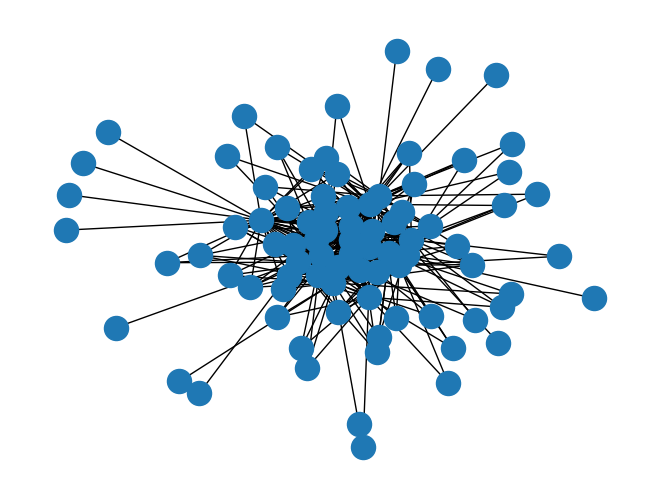

In [16]:


g_topo = communication_graph_from_df(df.iloc[:], entity_names=entity_names, keep_outsiders=False)
nx.draw(g_topo, cmap='Reds', with_labels=False)

In [17]:
len(g_topo)

84

In [18]:
# Order is according to entity_names
pos_dict = [ layout[name].tolist() for name in entity_names]
name_list = [name for name in entity_names]
edges_list = list(g_topo.edges)
risk_mean_list = risk_mean.tolist()
risk_cov_list = risk_cov.tolist()
g_f_adj = nx.adjacency_matrix(g_out, entity_names).todense().tolist()
color_list = [node_colors[name] for name in entity_names]
clusters = list(map(int, np.unique(list(clus_assgn.values())) ) )
extras = {'n_cluster': n_cluster, 'diam_xy': d_xy, 'diam_z': d_z, 'radius': r, 'clusters': clusters }  

In [22]:
from src.nre.network_plotting import pos2json

pos2json(r"../src/network_rendering/saves/net_data_medium1", namesArr = name_list, nodePosArr = pos_dict, topologyEdges=edges_list, riskArr=risk_mean_list,
         risk_cov = risk_cov_list, funcEdges=g_f_adj, entityColors=color_list, clusAssignments=clus_assgn, extras=extras)

In [8]:
from src.network_plotting import pos2json

# Standing Default Network
d_xy, d_z = 1.3, 2

pos_dict = [ ((np.random.rand(2) - 0.5) * d_xy).tolist() for _ in entity_names ]
name_list = [name for name in entity_names]
edges_list = []
risk_mean_list = [1 for _ in entity_names]
risk_cov_list = np.eye(len(entity_names)).tolist()
g_f_adj = np.eye(len(entity_names)).tolist() #np.zeros((len(entity_names), len(entity_names))).tolist()
clus_assgn = {name:0 for name in entity_names}

color_list = [(1.0, 1.0, 1.0, 1.0) for name in entity_names]
clusters = [0]
extras = {'n_cluster': 1, 'diam_xy': d_xy, 'diam_z': d_z, 'radius': d_xy/2, 'clusters': clusters }  


pos2json(r"../src/network_rendering/saves/net_data_medium0", namesArr = name_list, nodePosArr = pos_dict, topologyEdges=edges_list, riskArr=risk_mean_list,
         risk_cov = risk_cov_list, funcEdges=g_f_adj, entityColors=color_list, clusAssignments=clus_assgn, extras=extras)

In [22]:
import json

f = open(r"../src/network_rendering/saves/net_data_medium1.json")
data = json.load(f)
data.keys()

dict_keys(['namesArr', 'nodePosArr', 'topologyEdges', 'riskArr', 'risk_cov', 'funcEdges', 'entityColors', 'clusAssignments', 'extras'])

In [24]:
import json

f = open(r"../src/network_rendering/saves/net_data_medium0.json")
data = json.load(f)
data.keys()

dict_keys(['namesArr', 'nodePosArr', 'topologyEdges', 'riskArr', 'risk_cov', 'funcEdges', 'entityColors', 'clusAssignments', 'extras'])

In [34]:
key = 'funcEdges'
pd.DataFrame({key: (np.array(data[key]) ).flatten() }).describe()

,funcEdges
count,7056.000000
mean,0.031794
std,0.145120
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [35]:
pd.DataFrame({"degree":np.array(data[key]).sum(1) }).describe()

,degree
count,84.000000
mean,2.670688
std,1.297351
min,1.116096
25%,1.828352
50%,2.332592
75%,3.145865
max,8.272332


In [40]:
pd.DataFrame({"color_dict":np.array(data[key]).sum(1) }).describe()

,color_dict
count,84.000000
mean,2.670688
std,1.297351
min,1.116096
25%,1.828352
50%,2.332592
75%,3.145865
max,8.272332
